<a href="https://colab.research.google.com/github/d1mene/AI-Risk-Management/blob/master/market_risk_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Установка зависимостей

In [19]:
!pip install yfinance langchain langchain-groq langgraph plotly scipy -q

# Market Risk Analysis with LangGraph Agent
### VaR / CVaR & Stress Testing

**Стек:** `yfinance` · `LangChain` · `LangGraph` · `PyTorch` · `Pandas` · `Plotly`

---

**Архитектура проекта:**
```
yfinance → EDA returns → VaR (3 метода) → Stress Tests → LangGraph Agent
```

**Граф агента:**
```
START → fetch_data_node → risk_node → stress_node → analyst_node → END
```


## 1. Импорты и конфигурация

In [20]:
import os
import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
import torch
from scipy import stats
from typing import TypedDict, Annotated
import operator


from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langchain_groq import ChatGroq

warnings.filterwarnings("ignore")

api_key = None

with open('/content/groq_api_key.txt') as f:
  api_key = f.read()

os.environ["GROQ_API_KEY"] = api_key

TICKERS   = ["AAPL", "MSFT", "JPM", "GS", "XOM", "CVX", "TLT"]
START_DATE = "2018-01-01"
END_DATE   = "2024-12-31"
CONFIDENCE = 0.95
PORTFOLIO_VALUE = 1000000

## 2. Загрузка данных

Тянем исторические цены закрытия по всем тикерам через `yfinance`.  
Период **2018–2024** захватывает три разных рыночных режима:
- COVID (февраль–март 2020)
- Post-COVID recovery (2020–2021)
-  Rate hike cycle ФРС (2022–2023)


In [21]:
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]
raw.dropna(inplace=True)

returns = raw.pct_change().dropna()
log_returns = np.log(raw / raw.shift(1)).dropna()

print(f"Период:       {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Торговых дней: {len(returns)}")
print(f"\nСтатистика дневных доходностей:")
returns.describe().round(4)

[*********************100%***********************]  7 of 7 completed


Период:       2018-01-03 → 2024-12-30
Торговых дней: 1759

Статистика дневных доходностей:


Ticker,AAPL,CVX,GS,JPM,MSFT,TLT,XOM
count,1759.0000,1759.0000,1759.0000,1759.0000,1759.0000,1759.0000,1759.0000
mean,0.0012,0.0004,0.0007,0.0007,0.0011,-0.0000,0.0005
std,0.0192,0.0203,0.0195,0.0186,0.0182,0.0102,0.0195
min,-0.1286,-0.2212,-0.1271,-0.1496,-0.1474,-0.0667,-0.1222
25%,-0.0080,-0.0083,-0.0089,-0.0078,-0.0075,-0.0063,-0.0097
50%,0.0013,0.0008,0.0004,0.0007,0.0013,0.0001,0.0002
75%,0.0115,0.0093,0.0107,0.0091,0.0107,0.0058,0.0107
max,0.1198,0.2274,0.1758,0.1801,0.1422,0.0752,0.1269


## 3. EDA — исследование доходностей

### 3.1 Кумулятивные доходности


In [22]:
cum_returns = (1 + returns).cumprod()

fig = go.Figure()
for col in cum_returns.columns:
    fig.add_trace(go.Scatter(x=cum_returns.index, y=cum_returns[col], name=col, mode="lines"))

fig.update_layout(
    title="Кумулятивные доходности портфеля (2018–2024)",
    xaxis_title="Дата", yaxis_title="Рост $1",
    template="plotly_dark", height=450,
    legend=dict(orientation="h", y=-0.2)
)
fig.show()

### 3.2 Матрица корреляций

In [23]:
corr = returns.corr()

fig = px.imshow(
    corr, text_auto=".2f", color_continuous_scale="RdYlGn",
    title="Корреляционная матрица доходностей", zmin=-1, zmax=1
)
fig.update_layout(template="plotly_dark", height=500)
fig.show()

### 3.3 Распределение доходностей vs нормальное

In [24]:
fig = make_subplots(rows=2, cols=4, subplot_titles=TICKERS)
for i, ticker in enumerate(TICKERS):
    r, c = divmod(i, 4)
    x = np.linspace(returns[ticker].min(), returns[ticker].max(), 200)
    mu, sigma = returns[ticker].mean(), returns[ticker].std()
    fig.add_trace(go.Histogram(x=returns[ticker], histnorm="probability density",
                               name=ticker, showlegend=False, opacity=0.7,
                               marker_color="#00cc96"), row=r+1, col=c+1)
    fig.add_trace(go.Scatter(x=x, y=stats.norm.pdf(x, mu, sigma),
                             mode="lines", line=dict(color="red", width=2),
                             showlegend=False), row=r+1, col=c+1)

fig.update_layout(template="plotly_dark", height=500,
                  title="Распределение доходностей (зелёный) vs нормальное (красный)")
fig.show()

## 4. VaR и CVaR — три метода

| Метод | Суть |
|---|---|
| **Historical** | Эмпирический квантиль реальных доходностей |
| **Parametric** | Предполагаем нормальность, считаем через μ и σ |
| **Monte Carlo** | Симулируем 100 000 сценариев через PyTorch |


In [25]:
weights = np.ones(len(TICKERS)) / len(TICKERS)
portfolio_returns = returns @ weights

def historical_var(ret, confidence=CONFIDENCE):
    var = -np.percentile(ret, (1 - confidence) * 100)
    cvar = -ret[ret <= -var].mean()
    return var, cvar

def parametric_var(ret, confidence=CONFIDENCE):
    mu, sigma = ret.mean(), ret.std()
    z = stats.norm.ppf(1 - confidence)
    var = -(mu + z * sigma)
    cvar = -(mu - sigma * stats.norm.pdf(z) / (1 - confidence))
    return var, cvar

def monte_carlo_var(ret, confidence=CONFIDENCE, n_simulations=100_000):
    mu = torch.tensor(ret.mean(), dtype=torch.float32)
    sigma = torch.tensor(ret.std(), dtype=torch.float32)
    torch.manual_seed(42)
    simulated = torch.normal(mu.expand(n_simulations), sigma.expand(n_simulations))
    simulated_np = simulated.numpy()
    var = float(-np.percentile(simulated_np, (1 - confidence) * 100))
    cvar = float(-simulated_np[simulated_np <= -var].mean())
    return var, cvar

h_var, h_cvar = historical_var(portfolio_returns)
p_var, p_cvar = parametric_var(portfolio_returns)
m_var, m_cvar = monte_carlo_var(portfolio_returns)

var_df = pd.DataFrame({
    "Метод": ["Historical", "Parametric", "Monte Carlo"],
    "VaR, %": [h_var*100, p_var*100, m_var*100],
    "CVaR, %": [h_cvar*100, p_cvar*100, m_cvar*100],
    "VaR, $": [h_var*PORTFOLIO_VALUE, p_var*PORTFOLIO_VALUE, m_var*PORTFOLIO_VALUE],
    "CVaR, $": [h_cvar*PORTFOLIO_VALUE, p_cvar*PORTFOLIO_VALUE, m_cvar*PORTFOLIO_VALUE],
}).round(4)

print(f"Портфель: {PORTFOLIO_VALUE:,}$ | Confidence: {CONFIDENCE*100:.0f}%\n")
var_df

Портфель: 1,000,000$ | Confidence: 95%



,Метод,"VaR, %","CVaR, %","VaR, $","CVaR, $"
0,Historical,1.7237,2.8665,17237.3445,28664.9737
1,Parametric,1.9835,2.5045,19835.2600,25045.3315
2,Monte Carlo,1.9877,2.5063,19877.4915,25062.7305


### 4.1 Визуализация Historical VaR

In [26]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=portfolio_returns * 100, histnorm="probability density",
    name="Доходности", marker_color="#636efa", opacity=0.75, nbinsx=100
))
fig.add_vline(x=-h_var*100, line_color="red", line_dash="dash", line_width=2,
              annotation_text=f"VaR {CONFIDENCE*100:.0f}% = {-h_var*100:.2f}%",
              annotation_font_color="red")
fig.add_vline(x=-h_cvar*100, line_color="orange", line_dash="dot", line_width=2,
              annotation_text=f"CVaR = {-h_cvar*100:.2f}%",
              annotation_font_color="orange")
fig.update_layout(
    title="Распределение доходностей портфеля с Historical VaR/CVaR",
    xaxis_title="Дневная доходность (%)", yaxis_title="Плотность",
    template="plotly_dark", height=420
)
fig.show()

### 4.2 Rolling VaR (скользящее окно 252 дня)

In [27]:
window = 252
rolling_var = portfolio_returns.rolling(window).apply(
    lambda x: -np.percentile(x, (1 - CONFIDENCE) * 100)
)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.4, 0.6])
fig.add_trace(go.Bar(x=portfolio_returns.index, y=portfolio_returns*100,
                     name="Доходность", marker_color="#636efa", opacity=0.5), row=1, col=1)
fig.add_trace(go.Scatter(x=rolling_var.index, y=rolling_var*100,
                         name="Rolling VaR 95%", line=dict(color="red", width=2)), row=2, col=1)

fig.update_layout(template="plotly_dark", height=550,
                  title=f"Скользящий VaR 95% (окно {window} дней)")
fig.show()

## 5. Стресс-тестирование портфеля

Три исторических сценария:
- **COVID Crash** — февраль–март 2020
- **Rate Hike 2022** — январь–октябрь 2022
- **GFC 2008** — сентябрь–декабрь 2008 (параметрический шок)


In [28]:
scenarios = {
    "COVID (Feb–Mar 2020)": ("2020-02-19", "2020-03-23"),
    "Rate Hike 2022 (Jan–Oct)":   ("2022-01-03", "2022-10-13"),
}

stress_results = []

for name, (start, end) in scenarios.items():
    period = raw.loc[start:end]
    if len(period) < 2:
        continue
    total_return = (period.iloc[-1] / period.iloc[0] - 1)
    portfolio_loss = (total_return * weights).sum()
    stress_results.append({
        "Сценарий": name,
        "Просадка портфеля, %": round(portfolio_loss * 100, 2),
        "Потери, $": round(portfolio_loss * PORTFOLIO_VALUE, 0),
        "Дней в периоде": len(period)
    })

gfc_shock = -0.45
stress_results.append({
    "Сценарий": "GFC 2008 (параметрический -45%)",
    "Просадка портфеля, %": round(gfc_shock * 100, 2),
    "Потери, $": round(gfc_shock * PORTFOLIO_VALUE, 0),
    "Дней в периоде": 80
})

stress_df = pd.DataFrame(stress_results)
stress_df

,Сценарий,"Просадка портфеля, %","Потери, $",Дней в периоде
0,COVID (Feb–Mar 2020),-32.58,-325779.0,24
1,Rate Hike 2022 (Jan–Oct),-3.41,-34121.0,197
2,GFC 2008 (параметрический -45%),-45.00,-450000.0,80


### 5.1 Просадка по каждому активу в сценариях

In [29]:
asset_stress = {}
for name, (start, end) in scenarios.items():
    period = raw.loc[start:end]
    if len(period) >= 2:
        asset_stress[name] = (period.iloc[-1] / period.iloc[0] - 1) * 100

asset_stress_df = pd.DataFrame(asset_stress)

fig = go.Figure()
for col in asset_stress_df.columns:
    fig.add_trace(go.Bar(name=col, x=asset_stress_df.index, y=asset_stress_df[col]))

fig.update_layout(
    barmode="group", template="plotly_dark", height=430,
    title="Просадка активов по стресс-сценариям, %",
    xaxis_title="Актив", yaxis_title="Доходность, %"
)
fig.show()

In [30]:
@tool
def get_var_metrics(confidence_level: float = 0.95) -> str:
    """Возвращает VaR и CVaR портфеля тремя методами для заданного уровня доверия."""
    h_v, h_c = historical_var(portfolio_returns, confidence_level)
    p_v, p_c = parametric_var(portfolio_returns, confidence_level)
    m_v, m_c = monte_carlo_var(portfolio_returns, confidence_level)
    return (
        f"Уровень доверия: {confidence_level*100:.0f}%\n"
        f"Historical  — VaR: {h_v*100:.3f}%, CVaR: {h_c*100:.3f}% "
        f"(${h_v*PORTFOLIO_VALUE:,.0f} / ${h_c*PORTFOLIO_VALUE:,.0f})\n"
        f"Parametric  — VaR: {p_v*100:.3f}%, CVaR: {p_c*100:.3f}% "
        f"(${p_v*PORTFOLIO_VALUE:,.0f} / ${p_c*PORTFOLIO_VALUE:,.0f})\n"
        f"Monte Carlo — VaR: {m_v*100:.3f}%, CVaR: {m_c*100:.3f}% "
        f"(${m_v*PORTFOLIO_VALUE:,.0f} / ${m_c*PORTFOLIO_VALUE:,.0f})"
    )

@tool
def get_stress_test(scenario: str = "all") -> str:
    """Возвращает результаты стресс-тестирования. scenario: 'covid', 'rate_hike', 'gfc', или 'all'."""
    rows = []
    for _, row in stress_df.iterrows():
        rows.append(
            f"{row['Сценарий']}: просадка {row['Просадка портфеля, %']}%, "
            f"потери ${abs(row['Потери, $']):,.0f}"
        )
    return "\n".join(rows)

@tool
def get_asset_stats(ticker: str) -> str:
    """Возвращает статистику по конкретному активу из портфеля. ticker: AAPL, MSFT, JPM, GS, XOM, CVX, TLT"""
    if ticker not in TICKERS:
        return f"Тикер {ticker} не найден. Доступные: {TICKERS}"
    r = returns[ticker]
    sharpe = (r.mean() * 252) / (r.std() * np.sqrt(252))
    max_dd = ((raw[ticker] / raw[ticker].cummax()) - 1).min()
    return (
        f"Актив: {ticker}\n"
        f"Средняя дневная доходность: {r.mean()*100:.4f}%\n"
        f"Волатильность (годовая):    {r.std()*np.sqrt(252)*100:.2f}%\n"
        f"Sharpe Ratio:               {sharpe:.3f}\n"
        f"Max Drawdown:               {max_dd*100:.2f}%\n"
        f"Skewness:                   {r.skew():.3f}\n"
        f"Kurtosis:                   {r.kurtosis():.3f}"
    )

tools = [get_var_metrics, get_stress_test, get_asset_stats]
print("Инструменты агента зарегистрированы:", [t.name for t in tools])

Инструменты агента зарегистрированы: ['get_var_metrics', 'get_stress_test', 'get_asset_stats']


## 6. LangGraph — AI-агент риск-аналитик

### Архитектура агента

```
START
  └─→ risk_analyst_node  ←──────────────┐
          │                              │
          ├─→ [tool call] → tool_node ──┘
          │
          └─→ END
```

Агент получает данные о портфеле и умеет вызывать три инструмента:
- `get_var_metrics` — возвращает VaR/CVaR по всем методам
- `get_stress_test` — возвращает результаты стресс-тестов
- `get_asset_stats` — возвращает статистику по конкретному активу


### 6.1 Определение состояния и узлов графа

In [31]:
class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """Ты — старший риск-аналитик инвестиционного портфеля.
Портфель состоит из 7 активов: AAPL, MSFT, JPM, GS, XOM, CVX, TLT.
Общая стоимость портфеля: $1,000,000. Равновзвешенный.
Данные: 2018–2024.

Всегда используй доступные инструменты, чтобы получить актуальные цифры.
Отвечай структурированно: сначала цифры, затем интерпретация и рекомендации.
Общайся на русском языке."""

def risk_analyst_node(state: AgentState):
    messages = state["messages"]
    if not any(hasattr(m, "role") and m.role == "system" for m in messages
               if hasattr(m, "role")):
        from langchain_core.messages import SystemMessage
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: AgentState):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return END

tool_node = ToolNode(tools)

### 6.2 Сборка графа LangGraph

In [32]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("risk_analyst", risk_analyst_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "risk_analyst")
graph_builder.add_conditional_edges("risk_analyst", should_continue, {"tools": "tools", END: END})
graph_builder.add_edge("tools", "risk_analyst")

agent = graph_builder.compile()
print("Граф скомпилирован успешно")

Граф скомпилирован успешно


### 6.3 Визуализация графа

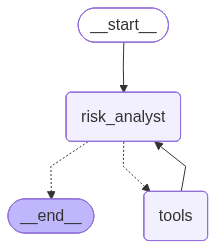

In [33]:
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print(agent.get_graph().draw_mermaid())

### 6.4 Запросы к агенту

Три сценария использования:
1. Общий риск-отчёт по портфелю
2. Анализ конкретного актива
3. Рекомендации по снижению риска


In [34]:
def ask_agent(question: str):
    print(f"\n{'='*60}")
    print(f"Вопрос: {question}")
    print('='*60)
    result = agent.invoke({"messages": [HumanMessage(content=question)]})
    for msg in result["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"\n🔧 Вызов инструмента: {tc['name']}({tc['args']})")
        elif isinstance(msg, AIMessage) and msg.content:
            print(f"\n Аналитик:\n{msg.content}")
    return result

In [35]:
result1 = ask_agent(
    "Проведи полный анализ рыночного риска нашего портфеля. "
    "Рассчитай VaR и CVaR, проверь стресс-сценарии и дай общую оценку."
)


Вопрос: Проведи полный анализ рыночного риска нашего портфеля. Рассчитай VaR и CVaR, проверь стресс-сценарии и дай общую оценку.

🔧 Вызов инструмента: get_var_metrics({'confidence_level': 0.95})

🔧 Вызов инструмента: get_stress_test({'scenario': 'all'})

 Аналитик:
**1️⃣ Ключевые цифры (на 95 % уровне доверия, портфель = $1 000 000, равновзвешенный)**  

| Метод | VaR (потеря в %) | VaR (в $) | CVaR (потеря в %) | CVaR (в $) |
|-------|------------------|----------|-------------------|-----------|
| **Historical** | **1,724 %** | **$17 237** | **2,866 %** | **$28 665** |
| **Parametric (Variance‑Covariance)** | **1,984 %** | **$19 835** | **2,505 %** | **$25 045** |
| **Monte‑Carlo (10 000 симуляций)** | **1,988 %** | **$19 877** | **2 506 %** | **$25 063** |

*VaR* – максимальная ожидаемая потеря за один торговый день с вероятностью 95 %.  
*CVaR* – средняя потеря в случае, когда реальная просадка превышает VaR (т.н. «tail risk»).

---

**2️⃣ Результаты стресс‑тестирования**

| Сцена

In [36]:
result2 = ask_agent(
    "Какой актив в нашем портфеле наиболее рискованный? "
    "Сравни JPM и XOM по ключевым метрикам риска."
)


Вопрос: Какой актив в нашем портфеле наиболее рискованный? Сравни JPM и XOM по ключевым метрикам риска.

🔧 Вызов инструмента: get_asset_stats({'ticker': 'AAPL'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'JPM'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'XOM'})

🔧 Вызов инструмента: get_var_metrics({'confidence_level': 0.95})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'MSFT'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'GS'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'CVX'})

 Аналитик:
**1️⃣ Ключевые цифры (по каждому активу, равный вес ≈ 14,3 % от портфеля)**  

| Тикер | Годовая волатильность | Max Drawdown | Sharpe Ratio | Skewness | Kurtosis |
|-------|----------------------|--------------|--------------|----------|----------|
| **AAPL** | 30,55 % | -38,52 % | 1,010 | -0,009 | 5,122 |
| **MSFT** | 28,89 % | -37,15 % | 0,975 | -0,023 | 6,797 |
| **JPM**  | 29,60 % | -43,63 % | 0,629 | 0,413 | 13,901 |
| **GS**   | 30,98 % | -48,75 % | 0,601 | 0,308

In [37]:
result3 = ask_agent(
    "Учитывая результаты стресс-тестов, как ты рекомендуешь "
    "пересмотреть веса портфеля для снижения риска? "
    "Обрати особое внимание на защитные активы."
)


Вопрос: Учитывая результаты стресс-тестов, как ты рекомендуешь пересмотреть веса портфеля для снижения риска? Обрати особое внимание на защитные активы.

🔧 Вызов инструмента: get_stress_test({'scenario': 'all'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'AAPL'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'MSFT'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'JPM'})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'GS'})

🔧 Вызов инструмента: get_var_metrics({'confidence_level': 0.95})

🔧 Вызов инструмента: get_asset_stats({'ticker': 'XOM'})

 Аналитик:
**1️⃣ Текущие цифры (равновзвешенный портфель)**  

| Тикер | Текущий вес | Сумма (USD) |
|-------|------------|-------------|
| AAPL  | 14,29 %    | 142 857 $ |
| MSFT  | 14,29 %    | 142 857 $ |
| JPM   | 14,29 %    | 142 857 $ |
| GS    | 14,29 %    | 142 857 $ |
| XOM   | 14,29 %    | 142 857 $ |
| CVX   | 14,29 %    | 142 857 $ |
| TLT   | 14,29 %    | 142 857 $ |
| **Итого** | **100 %** | **1 000 000 $** |

*Стрес

## 7. Итоги

| Блок | Что сделано | Навыки |
|---|---|---|
| **Данные** | Загрузка 7 активов за 6 лет | `yfinance`, `pandas` |
| **EDA** | Корреляции, распределения, кумдоходности | `plotly` |
| **VaR** | Historical, Parametric, Monte Carlo | `scipy`, `pytorch` |
| **Stress Tests** | COVID, Rate Hike 2022, GFC | `pandas` |
| **Agent** | LangGraph граф с 3 инструментами | `langchain`, `langgraph` |

### Возможные улучшения
- Добавить **GARCH-модель** волатильности вместо константной σ
- Добавить **Expected Shortfall** по Basel III
- Расширить портфель российскими бумагами через MOEX API
- Добавить **Backtesting VaR** (проверка нарушений)
- Подключить **реальные новости** через web_search tool в агенте
